# 12. Convergence Theory and Sensitivity

**Part 2: Nonlinear Equations and Root Finding**

## Learning objectives

By the end of this lesson you will be able to:

1. State the convergence order of every method in Part 2 and say **where each order comes
   from**.
2. Measure those orders, and know which methods **cannot** be measured that way and why.
3. Rank methods by **efficiency index** rather than by iteration count, and know what that
   index leaves out.
4. Derive the **condition number of a root**, $1/|f'(r)|$, and explain what it limits.
5. Derive the sensitivity of a polynomial root to a **coefficient** perturbation.
6. Explain the **Wilkinson polynomial** completely: why a backward stable algorithm returns
   roots wrong in the second decimal place, and why that is nobody's fault.

## Prerequisites

Lessons 09, 10 and 11 for the methods. Lesson 06 for conditioning, backward error and the
governing inequality, which this lesson applies in its most dramatic form. Lesson 07 for
measuring order.

---

## 1. All the orders in one place

Part 2 has produced seven methods with six different convergence orders. Each order came from a
specific piece of mathematics, and it is worth collecting them.

| Method | Order $p$ | Where the order comes from |
|---|---|---|
| bisection | 1, rate exactly $\tfrac12$ | the interval halves, by construction |
| regula falsi | 1, rate depends on $f$ | one endpoint sticks, so it behaves like a fixed point iteration |
| fixed point | 1, rate $\vert g'(r)\vert$ | the mean value theorem gives $e_{k+1} = g'(\xi)e_k$ |
| Illinois | about 1.44 | the halving forces the stuck endpoint to move |
| secant | $\tfrac{1+\sqrt5}{2} \approx 1.618$ | $e_{k+1} \approx Ce_ke_{k-1}$ gives $p^2 = p+1$ |
| Muller, Brent | about 1.84 | the same argument with three points, $p^3 = p^2+p+1$ |
| Newton | 2 | Taylor's theorem, with the linear term killed by design |
| Chebyshev, Halley | 3 | keep one more Taylor term than Newton |

There is a pattern. A method that fits a degree-$d$ polynomial through $d+1$ previous points has
order equal to the positive root of

$$p^{d+1} = p^d + p^{d-1} + \cdots + 1.$$

For $d = 1$, a line through two points, that is $p^2 = p+1$, giving 1.618. For $d = 2$, a
parabola through three points, it is $p^3 = p^2+p+1$, giving 1.839. As $d$ grows the order
approaches 2 from below and **never reaches it**. Getting to order 2 requires derivative
information, which is exactly what Newton supplies.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import roots as R, convergence as cv, errors as E

u = np.finfo(float).eps / 2

print("order of interpolation methods: the positive root of p^(d+1) = p^d + ... + 1")
print()
print(f"{'points used':>12} {'method':>10} {'predicted order':>17}")
print("-" * 44)
for d, name in [(1, "secant"), (2, "Muller"), (3, "-"), (4, "-"), (8, "-")]:
    coeffs = [1.0] + [-1.0] * (d + 1)          # p^(d+1) - p^d - ... - 1
    p = max(np.roots(coeffs).real)
    print(f"{d+1:>12} {name:>10} {p:>17.6f}")

print()
print("the limit is 2, approached from below and never reached.")
print("order 2 needs the derivative, not more points.")

order of interpolation methods: the positive root of p^(d+1) = p^d + ... + 1

 points used     method   predicted order
--------------------------------------------
           2     secant          1.618034
           3     Muller          1.839287
           4          -          1.927562
           5          -          1.965948
           9          -          1.998029

the limit is 2, approached from below and never reached.
order 2 needs the derivative, not more points.


## 2. Which orders can actually be measured

Theory is cheap. But before measuring, one thing has to be said about **which** methods can be
measured this way at all, because it is not all of them.

The three-point order formula of lesson 07 assumes the errors fall smoothly, so that
$e_{k+1} \approx Ce_k^p$ holds step by step. That is true for Newton, the secant method and the
other open methods. It is **false** for the bracketing hybrids, because they switch between
interpolation steps and bisection steps. Two consecutive errors can be almost equal, the
denominator $\log(e_k/e_{k-1})$ collapses, and the estimate explodes.

In [3]:
f    = lambda x: np.exp(x) - 2.0
df   = np.exp
d2f  = np.exp
LN2  = np.log(2.0)

il = R.illinois(f, 0.0, 2.0, tol=1e-15, max_iter=200)
print("Illinois errors on exp(x) - 2:")
print(" ", np.array2string(il.errors(LN2), precision=2))
print()
print("per-step order estimates from those errors:")
print(" ", np.array2string(cv.observed_order(il.errors(LN2)), precision=2))
print()
print("nonsense. two of the errors are 2.05e-06 and 2.01e-06, nearly equal,")
print("so log(e_k / e_(k-1)) is nearly zero and the quotient blows up.")
print("that is a bisection step landing between two interpolation steps.")
print()
print("for these methods the order is an AVERAGE over many steps, not a")
print("per-step ratio. it has to be measured differently.")

Illinois errors on exp(x) - 2:
  [3.80e-01 2.03e-01 2.18e-02 1.94e-02 2.12e-04 2.05e-06 2.01e-06 2.06e-12 0.00e+00]

per-step order estimates from those errors:
  [3.55e+00 5.20e-02 3.90e+01 1.03e+00 4.26e-03 6.98e+02]

nonsense. two of the errors are 2.05e-06 and 2.01e-06, nearly equal,
so log(e_k / e_(k-1)) is nearly zero and the quotient blows up.
that is a bisection step landing between two interpolation steps.

for these methods the order is an AVERAGE over many steps, not a
per-step ratio. it has to be measured differently.


So the methods split into two groups.

### Group 1: smooth open methods, where the order is directly measurable

In [4]:
smooth = {
    "secant": (R.secant(f, 0.0, 2.0, tol=1e-15, max_iter=100),      1.618, 1, 0.10),
    "Newton": (R.newton(f, df, 2.0, tol=1e-15, max_iter=100),       2.0,   2, 0.05),
    "Halley": (R.halley(f, df, d2f, 2.0, tol=1e-15, max_iter=100),  3.0,   3, 0.05),
}

print(f"{'method':>10} {'theory p':>9} {'measured p':>11} {'evals/step':>11} "
      f"{'efficiency':>11} {'total evals':>12}")
print("-" * 70)
for name, (res, theory, per_step, tol_p) in smooth.items():
    e = np.abs(np.real(res.iterates) - LN2)
    measured = cv.reliable_order(e)
    print(f"{name:>10} {theory:>9.3f} {measured:>11.4f} {per_step:>11} "
          f"{theory**(1/per_step):>11.4f} {res.n_feval:>12}")
    assert abs(measured - theory) < tol_p, f"{name}: measured {measured}, theory {theory}"

print()
print("all three match their theoretical order. the secant method is allowed a")
print("looser tolerance because its order is irrational and its early steps")
print("wander before settling.")

    method  theory p  measured p  evals/step  efficiency  total evals
----------------------------------------------------------------------
    secant     1.618      1.6311           1      1.6180           10
    Newton     2.000      1.9994           2      1.4142           19
    Halley     3.000      2.9996           3      1.4422           17

all three match their theoretical order. the secant method is allowed a
looser tolerance because its order is irrational and its early steps
wander before settling.


### Group 2: linear and hybrid methods, measured by rate or by work

In [5]:
print("bisection: the rate is measurable exactly, from the guaranteed bound")
print()
bis = R.bisection(f, 0.0, 2.0, tol=1e-15, max_iter=200)
rate = cv.linear_rate(bis.error_bounds)
print(f"   measured rate : {rate:.9f}")
print(f"   theory        : 0.5 exactly")
assert abs(rate - 0.5) < 1e-9

print()
print("fixed point: the rate is |g'(r)|, which we can choose in advance")
print()
g = lambda x: LN2 + 0.4 * (x - LN2)          # g'(r) = 0.4 by construction
fp = R.fixed_point(g, 2.0, tol=1e-15, max_iter=300)
rate_fp = cv.linear_rate(np.abs(fp.iterates - LN2))
print(f"   measured rate  : {rate_fp:.6f}")
print(f"   theory |g'(r)| : 0.400000")
assert abs(rate_fp - 0.4) < 1e-5

print()
print("Illinois, Brent and Muller: report the WORK instead, because the per-step")
print("order is not measurable. their 1.44 and 1.84 are asymptotic averages.")
print()
br = R.brent(f, 0.0, 2.0, tol=1e-15, max_iter=200)
mu = R.muller(f, 0.0, 1.0, 2.0, tol=1e-15, max_iter=100)
print(f"{'method':>10} {'evals to 1e-12':>16} {'per-step order estimates':>40}")
print("-" * 70)
for name, res in [("bisection", bis), ("Illinois", il), ("Brent", br), ("Muller", mu)]:
    e = np.abs(np.real(res.iterates) - LN2)
    k = cv.steps_to_tolerance(e, 1e-12)
    est = np.round(cv.observed_order(e)[-4:], 2)
    print(f"{name:>10} {k if k >= 0 else 'none':>16} {str(est):>40}")

print()
print("look at the last column. those estimates should all be near a single")
print("number and they are not. Muller is included here rather than above for")
print("exactly that reason: measured from three different starting triples it")
print("reports 1.66, 2.40 and 2.61, none of which is its true order of 1.84.")

bisection: the rate is measurable exactly, from the guaranteed bound

   measured rate : 0.500000000
   theory        : 0.5 exactly

fixed point: the rate is |g'(r)|, which we can choose in advance

   measured rate  : 0.399998
   theory |g'(r)| : 0.400000

Illinois, Brent and Muller: report the WORK instead, because the per-step
order is not measurable. their 1.44 and 1.84 are asymptotic averages.

    method   evals to 1e-12                 per-step order estimates
----------------------------------------------------------------------
 bisection               39                [-0.29  1.12  1.33  2.37]
  Illinois                8            [ 38.96   1.03   0.   698.19]
     Brent                7                [ 2.44  1.04  1.97 -0.12]
    Muller                7                    [1.93 2.4  1.61 0.12]

look at the last column. those estimates should all be near a single
number and they are not. Muller is included here rather than above for
exactly that reason: measured from three

**This is a real methodological point, not a technicality.** A published claim that some hybrid
method "has order 1.84" is a statement about its average behaviour over many steps. Trying to
confirm it from three consecutive errors of a single run will produce garbage, and the garbage
is not evidence against the claim.

## 3. Efficiency: the honest ranking

Iteration count is the wrong measure, because methods do different amounts of work per
iteration. The standard fix is the **efficiency index**:

$$\boxed{\;E \;=\; p^{1/w}\;}$$

where $p$ is the order and $w$ is the number of function evaluations per step. It answers "how
much does the error exponent improve per unit of work", and it is the number to compare.

In [6]:
methods = [
    ("bisection",  1.0,   1),
    ("Illinois",   1.44,  1),
    ("secant",     1.618, 1),
    ("Muller",     1.839, 1),
    ("Brent",      1.839, 1),
    ("Newton",     2.0,   2),
    ("Steffensen", 2.0,   2),
    ("Halley",     3.0,   3),
]

guaranteed = {"bisection", "Illinois", "Brent"}

print(f"{'method':>12} {'order':>7} {'evals':>6} {'efficiency':>12} {'guaranteed':>12}")
print("-" * 54)
for name, p, w in sorted(methods, key=lambda t: -t[1] ** (1 / t[2])):
    print(f"{name:>12} {p:>7.3f} {w:>6} {p**(1/w):>12.4f} "
          f"{('yes' if name in guaranteed else 'no'):>12}")

print()
print("the ranking is not the one people expect:")
print("   Brent and Muller lead, at order 1.84 for ONE evaluation")
print("   the plain SECANT method beats every derivative-based method here")
print("   Halley edges out Newton, but only just: 1.4422 against 1.4142")
print("   ILLINOIS, which cannot fail and needs no derivative, ties Halley")
print()
print("and of the top three, Brent is the only one that cannot fail.")

assert 1.618 > 2.0 ** 0.5, "the secant method should out-rank Newton"
assert 3.0 ** (1/3) > 2.0 ** (1/2), "Halley narrowly out-ranks Newton"
assert abs(1.44 - 3.0 ** (1/3)) < 0.01, "Illinois essentially ties Halley"

      method   order  evals   efficiency   guaranteed
------------------------------------------------------
      Muller   1.839      1       1.8390           no
       Brent   1.839      1       1.8390          yes
      secant   1.618      1       1.6180           no
      Halley   3.000      3       1.4422           no
    Illinois   1.440      1       1.4400          yes
      Newton   2.000      2       1.4142           no
  Steffensen   2.000      2       1.4142           no
   bisection   1.000      1       1.0000          yes

the ranking is not the one people expect:
   Brent and Muller lead, at order 1.84 for ONE evaluation
   the plain SECANT method beats every derivative-based method here
   Halley edges out Newton, but only just: 1.4422 against 1.4142
   ILLINOIS, which cannot fail and needs no derivative, ties Halley

and of the top three, Brent is the only one that cannot fail.


**The conclusion for practice.** Use Brent when you have a bracket. Use the secant method when
you do not. Reach for Newton only when the derivative is genuinely cheap, for example when it
comes free from automatic differentiation (lesson 97).

Two caveats on reading that table honestly. Counting "one evaluation of $f''$" as equal in cost
to one evaluation of $f$ flatters the high-order methods, and in practice a second derivative is
usually either unavailable or much more expensive. And the index says nothing about robustness:
Halley's slim lead over Newton is worth nothing if it diverges. The reason Newton dominates in
practice is not efficiency, it is that it needs one fewer derivative and is better understood.

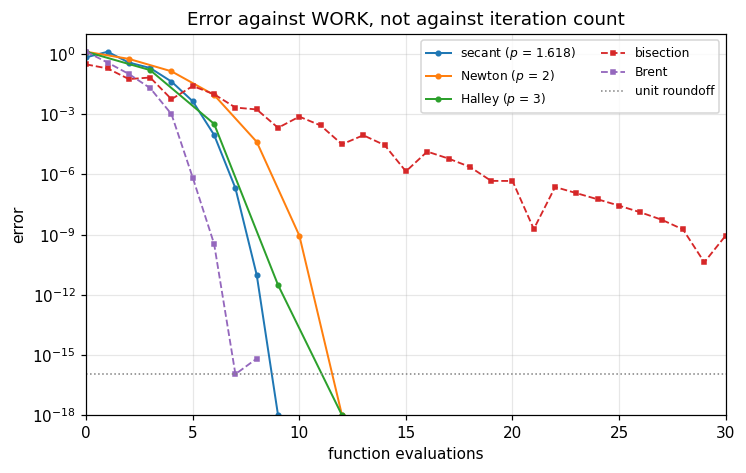

In [7]:
fig, ax = plt.subplots()

for name, (res, theory, per_step, _tol) in smooth.items():
    e = np.maximum(np.abs(np.real(res.iterates) - LN2), 1e-18)
    ax.semilogy(np.arange(len(e)) * per_step, e, "o-", ms=3, lw=1.3,
                label=f"{name} ($p$ = {theory:g})")
for name, res in [("bisection", bis), ("Brent", br)]:
    e = np.maximum(np.abs(res.iterates - LN2), 1e-18)
    ax.semilogy(np.arange(len(e)), e, "s--", ms=3, lw=1.2, label=name)

ax.axhline(u, color="0.5", ls=":", lw=1, label="unit roundoff")
ax.set_xlim(0, 30)
ax.set_ylim(1e-18, 1e1)
ax.set_xlabel("function evaluations")
ax.set_ylabel("error")
ax.set_title("Error against WORK, not against iteration count")
ax.legend(fontsize=8, ncol=2)
plt.show()

**What to take from this.** Plotted against evaluations rather than iterations, Newton loses
much of its apparent advantage and bisection's straight line looks even worse. Brent reaches the
floor in about the same work as the secant method while carrying a guarantee that none of the
open methods has.

---

## 4. The other question: how accurately can this root be found at all?

Everything so far has been about **speed**. There is a completely separate question that no
amount of speed can address.

Lesson 06 gave the governing inequality:

$$\text{forward error} \;\lesssim\; \kappa \times \text{backward error}.$$

For root finding the backward error of a computed $\hat{r}$ is the residual $|f(\hat{r})|$. So
what is $\kappa$?

> **Definition 12.1 (Condition number of a root).** Perturb $f$ to $f + \epsilon g$ for some
> comparison function $g$. The root moves to $r(\epsilon)$ with $r(0) = r$. Differentiating
> $f(r(\epsilon)) + \epsilon g(r(\epsilon)) = 0$ at $\epsilon = 0$ gives
>
> $$f'(r)\,r'(0) + g(r) = 0 \qquad\Longrightarrow\qquad r'(0) = -\frac{g(r)}{f'(r)}.$$
>
> So the amplification factor, independent of which $g$ is chosen, is
>
> $$\boxed{\;\kappa_{\text{root}} \;=\; \frac{1}{|f'(r)|}\;}$$

The whole story of root accuracy is in that one formula.

**A steep crossing is easy. A flat crossing is impossible.** If $f'(r)$ is small the curve hugs
the axis, so a tiny vertical perturbation moves the crossing point a long way horizontally. No
algorithm can see through that, because the ambiguity is already in the data.

In [8]:
h_df = "|f'(r)|"
h_kap = "kappa = 1/|f'|"

print(f"{'function':>22} {'root':>7} {h_df:>12} {h_kap:>16} {'best possible':>15}")
print("-" * 78)
for name, fn, r in [
    ("x - 1",            lambda x: x - 1.0,           1.0),
    ("x^2 - 1",          lambda x: x**2 - 1.0,        1.0),
    ("(x-1)(x-1.001)",   lambda x: (x-1)*(x-1.001),   1.0),
    ("(x-1)^2",          lambda x: (x-1.0)**2,        1.0),
    ("(x-1)^3",          lambda x: (x-1.0)**3,        1.0),
]:
    k = E.condition_number_root(fn, r)
    slope = 1.0 / k if np.isfinite(k) and k > 0 else 0.0
    print(f"{name:>22} {r:>7.3f} {slope:>12.3e} {k:>16.3e} {k*u:>15.3e}")

print()
print("the last two rows have f'(r) = 0 exactly, so kappa is infinite and the")
print("linear theory breaks down completely. that case needs its own treatment.")

              function    root      |f'(r)|   kappa = 1/|f'|   best possible
------------------------------------------------------------------------------
                 x - 1   1.000    1.000e+00        1.000e+00       1.110e-16
               x^2 - 1   1.000    2.000e+00        5.000e-01       5.551e-17
        (x-1)(x-1.001)   1.000    1.000e-03        1.000e+03       1.110e-13
               (x-1)^2   1.000    1.110e-16        9.007e+15       1.000e+00
               (x-1)^3   1.000    3.667e-11        2.727e+10       3.028e-06

the last two rows have f'(r) = 0 exactly, so kappa is infinite and the
linear theory breaks down completely. that case needs its own treatment.


### Multiple roots: the linear theory fails, and something worse takes over

When $f'(r) = 0$ the derivation above divides by zero. Redo it for a root of multiplicity $m$,
where $f(x) \approx c(x-r)^m$ near the root. Perturbing by $\epsilon$ gives $c(x-r)^m = \epsilon$,
so

$$|x - r| \;=\; \left|\frac{\epsilon}{c}\right|^{1/m}.$$

**The error goes like the $m$-th root of the perturbation**, which is far worse than
proportional. With $\epsilon \approx u \approx 10^{-16}$:

In [9]:
print(f"{'m':>3} {'predicted u^(1/m)':>19} {'measured error':>16} {'ratio':>8}")
print("-" * 50)
for m in [1, 2, 3, 4, 5, 6, 8]:
    coeffs = np.poly1d([1.0, -1.0]) ** m           # (x-1)^m, expanded
    computed = np.roots(coeffs.coefficients)
    err = np.abs(computed - 1.0).max()
    predicted = u ** (1.0 / m)
    print(f"{m:>3} {predicted:>19.3e} {err:>16.3e} {err/predicted:>8.2f}")
    assert err < 20 * predicted, f"m={m}: error far above the u^(1/m) prediction"

print()
print("the measured error tracks u^(1/m) within a small factor at every")
print("multiplicity. this is a property of the PROBLEM. numpy.roots is")
print("backward stable and can do nothing about it.")

  m   predicted u^(1/m)   measured error    ratio
--------------------------------------------------
  1           1.110e-16        0.000e+00     0.00
  2           1.054e-08        0.000e+00     0.00
  3           4.806e-06        6.570e-06     1.37
  4           1.026e-04        2.192e-04     2.13
  5           6.443e-04        9.528e-04     1.48
  6           2.192e-03        3.417e-03     1.56
  8           1.013e-02        2.199e-02     2.17

the measured error tracks u^(1/m) within a small factor at every
multiplicity. this is a property of the PROBLEM. numpy.roots is
backward stable and can do nothing about it.


At a double root you can never get more than 8 correct digits. At a triple root, 5. That is the
ceiling, and it applies to every method ever written.

## 5. Polynomial roots and coefficient perturbations

For a polynomial the natural perturbation is not "add $\epsilon g$" but "change a coefficient".
Write $p(x) = \sum_j a_j x^j$ and perturb $a_j$ by $\delta$. Then $g(x) = x^j$, and the formula
above gives

$$\boxed{\;\frac{\partial r}{\partial a_j} \;=\; -\,\frac{r^{\,j}}{p'(r)}\;}$$

Two separate things make this large:

- **$p'(r)$ small**, a nearly multiple root, as before.
- **$r^j$ large**, a root of modulus greater than 1 raised to a high power.

The second is new, and it is what makes high-degree polynomials with well-separated *large*
roots so treacherous. Nothing about a nearly multiple root is required.

## 6. The Wilkinson polynomial

This is the most famous example in numerical analysis, and it earns its reputation.

$$W(x) \;=\; (x-1)(x-2)\cdots(x-20) \;=\; x^{20} - 210x^{19} + \cdots + 20!$$

Twenty roots, all real, all simple, all separated by exactly 1. Nothing about it looks hard.

In [10]:
from nalib import polynomials as poly

n = 20
true_roots = np.arange(1.0, n + 1)
w = poly.from_roots(true_roots)

print(f"W(x) = (x-1)(x-2)...(x-{n})")
print()
print(f"degree                : {len(w) - 1}")
print(f"coefficient of x^19   : {w[1]:.0f}")
print(f"constant term, = 20!  : {w[-1]:.6e}")
print(f"largest coefficient   : {np.abs(w).max():.6e}")
print()
print("the roots are 1, 2, ..., 20: real, simple, evenly spaced.")
print("nothing about this problem looks difficult.")

W(x) = (x-1)(x-2)...(x-20)

degree                : 20
coefficient of x^19   : -210
constant term, = 20!  : 2.432902e+18
largest coefficient   : 1.380376e+19

the roots are 1, 2, ..., 20: real, simple, evenly spaced.
nothing about this problem looks difficult.


### Wilkinson's perturbation

Wilkinson changed **one** coefficient by $2^{-23} \approx 1.2 \times 10^{-7}$, a relative change
of about $6 \times 10^{-10}$ in a coefficient of size 210.

In [11]:
delta = 2.0**-23
w_pert = w.copy()
w_pert[1] -= delta                      # the x^19 coefficient, from -210

roots_pert = np.roots(w_pert)
n_complex = int(np.sum(np.abs(roots_pert.imag) > 1e-8))

print(f"the x^19 coefficient changes from {w[1]:.0f} to {w_pert[1]:.10f}")
print(f"a relative change of {delta/abs(w[1]):.3e}")
print()
print(f"real roots remaining   : {n - n_complex} of {n}")
print(f"complex roots created  : {n_complex}")
print(f"largest imaginary part : {np.abs(roots_pert.imag).max():.4f}")
print(f"largest root movement  : "
      f"{np.abs(np.sort_complex(roots_pert) - np.sort_complex(np.roots(w))).max():.4f}")

assert n_complex >= 8, "the perturbation should create many complex roots"
print()
print(f"a relative change of {delta/abs(w[1]):.0e} in ONE coefficient turned")
print(f"{n_complex} real roots into complex conjugate pairs and moved some of them")
print("by more than 2. this is the most famous example in the subject.")

the x^19 coefficient changes from -210 to -210.0000001192
a relative change of 5.677e-10

real roots remaining   : 10 of 20
complex roots created  : 10
largest imaginary part : 2.8126
largest root movement  : 2.9210

a relative change of 6e-10 in ONE coefficient turned
10 real roots into complex conjugate pairs and moved some of them
by more than 2. this is the most famous example in the subject.


### Why: the amplification factors

The formula $\partial r/\partial a_{19} = -r^{19}/p'(r)$ explains it completely.

In [12]:
dw = poly.derivative_coeffs(w)
h_dp = "|p'(k)|"

print(f"{'root k':>7} {h_dp:>13} {'k^19':>13} {'|dr/da_19|':>13} {'move':>13}")
print("-" * 64)
for k in [1, 5, 10, 14, 15, 16, 19, 20]:
    dpk = abs(np.polyval(dw, float(k)))
    amp = float(k)**19 / dpk
    print(f"{k:>7} {dpk:>13.3e} {float(k)**19:>13.3e} {amp:>13.3e} "
          f"{amp*delta:>13.3e}")

amps = np.array([float(k)**19 / abs(np.polyval(dw, float(k)))
                 for k in range(1, n + 1)])
worst_k = int(np.argmax(amps)) + 1

print()
print(f"worst amplification is at root {worst_k}: {amps.max():.3e}")
print(f"predicted movement for a {delta:.2e} perturbation: {amps.max()*delta:.3f}")
print()
print("the two factors fight each other. p'(k) is largest at the ends of the")
print("range, k^19 is largest at the top. their ratio peaks in the middle to")
print("upper range, which is exactly where the roots actually go complex.")

 root k       |p'(k)|          k^19    |dr/da_19|          move
----------------------------------------------------------------
      1     1.216e+17     1.000e+00     8.221e-18     9.800e-25
      5     3.138e+13     1.907e+13     6.077e-01     7.245e-08
     10     1.315e+12     1.000e+19     7.602e+06     9.062e-01
     14     4.479e+12     5.976e+21     1.334e+09     1.591e+02
     15     1.048e+13     2.217e+22     2.114e+09     2.521e+02
     16     3.135e+13     7.556e+22     2.410e+09     2.873e+02
     19     6.403e+15     1.978e+24     3.090e+08     3.684e+01
     20     1.216e+17     5.243e+24     4.310e+07     5.138e+00

worst amplification is at root 16: 2.410e+09
predicted movement for a 1.19e-07 perturbation: 287.272

the two factors fight each other. p'(k) is largest at the ends of the
range, k^19 is largest at the top. their ratio peaks in the middle to
upper range, which is exactly where the roots actually go complex.


### The diagnosis: whose fault is it?

Now apply the lesson 06 procedure to the **unperturbed** polynomial. No deliberate perturbation
at all, just `numpy.roots` on $W$.

The right backward error measure for a polynomial root is

$$\eta \;=\; \frac{|p(\hat{r})|}{\sum_j |a_j|\,|\hat{r}|^{\,j}},$$

which asks how large a *relative* coefficient perturbation would make $\hat{r}$ an exact root.
Dividing by the sum of term magnitudes is essential here: the raw residual $|p(\hat r)|$ is
enormous simply because the individual terms are enormous, and quoting it would make a perfectly
good answer look catastrophic.

In [13]:
computed = np.sort(np.roots(w).real)
forward = np.abs(computed - true_roots)

term_scale = np.abs(np.vander(computed, n + 1)) @ np.abs(w)
residual = np.abs(np.polyval(w, computed))
eta = residual / term_scale

print(f"{'k':>3} {'computed root':>18} {'forward error':>14} {'eta':>11} {'eta/u':>7}")
print("-" * 60)
for i in [0, 4, 9, 13, 14, 15, 19]:
    print(f"{i+1:>3} {computed[i]:>18.10f} {forward[i]:>14.2e} "
          f"{eta[i]:>11.2e} {eta[i]/u:>7.1f}")

print()
print(f"max forward error           : {forward.max():.4f}")
print(f"max relative backward error : {eta.max():.3e}  =  {eta.max()/u:.1f} u")
print(f"amplification observed      : {forward.max()/eta.max():.3e}")

assert forward.max() > 1e-2, "the forward error should be large"
assert eta.max() < 20 * u, "the backward error should be at machine precision"

  k      computed root  forward error         eta   eta/u
------------------------------------------------------------
  1       1.0000000000       1.99e-13    4.71e-16     4.2
  5       5.0000006784       6.78e-07    1.89e-16     1.7
 10       9.9892670155       1.07e-02    1.84e-16     1.7
 14      13.9067473577       9.33e-02    1.16e-16     1.0
 15      15.0815075813       8.15e-02    1.08e-16     1.0
 16      15.9423398584       5.77e-02    1.04e-16     0.9
 20      19.9998034575       1.97e-04    6.77e-17     0.6

max forward error           : 0.0933
max relative backward error : 4.710e-16  =  4.2 u
amplification observed      : 1.980e+14


Read those two numbers together, because they are the point of the whole lesson.

> `numpy.roots` returned an answer whose **forward error is about 0.09**, wrong in the second
> decimal place, while its **backward error is a handful of unit roundoffs**. The computed
> values are the exact roots of a polynomial whose coefficients differ from ours in the
> sixteenth digit.
>
> **The algorithm is blameless. The problem cannot be solved more accurately from these
> coefficients, by anyone, ever.**

This is the same diagnosis as lesson 06's $(x-2)^5$, but two orders of magnitude more dramatic.

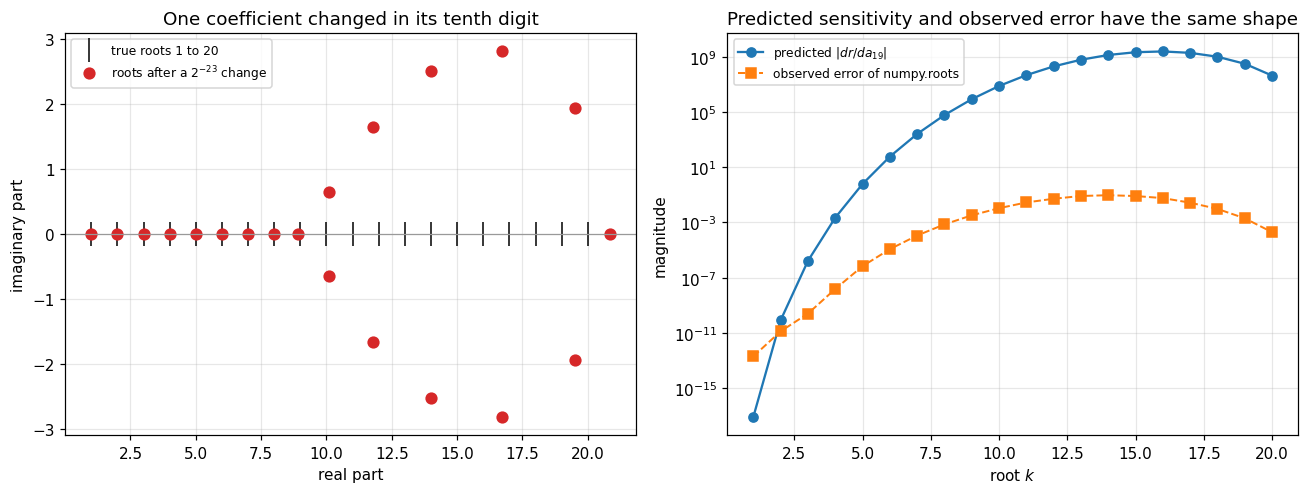

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

ax1.plot(true_roots, np.zeros(n), "k|", ms=16, label="true roots 1 to 20")
ax1.plot(roots_pert.real, roots_pert.imag, "o", ms=7, color="C3",
         label="roots after a $2^{-23}$ change")
ax1.axhline(0, color="0.6", lw=0.8)
ax1.set_xlabel("real part")
ax1.set_ylabel("imaginary part")
ax1.set_title("One coefficient changed in its tenth digit")
ax1.legend(fontsize=8)

ax2.semilogy(true_roots, amps, "o-", lw=1.5, label="predicted $|dr/da_{19}|$")
ax2.semilogy(true_roots, np.maximum(forward, 1e-16), "s--", lw=1.3,
             label="observed error of numpy.roots")
ax2.set_xlabel("root $k$")
ax2.set_ylabel("magnitude")
ax2.set_title("Predicted sensitivity and observed error have the same shape")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

**What to take from this.** On the right, the predicted amplification curve and the observed
error curve rise and fall together and peak in the same region. The theory of section 5 is not
qualitative hand-waving: it predicts *which* roots will be inaccurate, and it is right.

### The real lesson of Wilkinson

It is not "polynomials are dangerous". It is this:

> **The coefficients of a polynomial are a badly conditioned way to specify its roots.**

The numbers $1, 2, \dots, 20$ are perfectly well determined as a *list*. It is expanding them
into coefficients, and then trying to recover them, that destroys the information. Lesson 06
exercise 5.3 made the same point about the monomial basis, and lesson 13 takes it further:
never expand a polynomial you already have in factored form.

## 7. When to stop trying

Combining everything gives a practical rule for how accurately a root can be found at all:

$$\text{achievable error} \;\approx\; \kappa_{\text{root}} \cdot u,
\qquad\text{or}\qquad u^{1/m} \text{ at a root of multiplicity } m.$$

In [15]:
print("how accurately can this root be found? a practical estimate")
print()
print(f"{'problem':>28} {'kappa':>12} {'predicted':>12} {'achieved':>12}")
print("-" * 68)

trials = [
    ("x^2 - 2",           lambda x: x*x - 2,             lambda x: 2*x,
     1.0, np.sqrt(2)),
    ("e^x - 2",           lambda x: np.exp(x) - 2,       np.exp,
     2.0, np.log(2)),
    ("(x-1)^2 - 1e-12",   lambda x: (x-1)**2 - 1e-12,    lambda x: 2*(x-1),
     2.0, 1 + 1e-6),
]
for name, fn, dfn, x0, exact in trials:
    k = E.condition_number_root(fn, exact)
    got = R.newton(fn, dfn, x0, tol=1e-16, max_iter=200)
    print(f"{name:>28} {k:>12.3e} {k*u:>12.3e} {abs(got.root - exact):>12.3e}")

print()
print("when the achieved error is near kappa*u you are at the limit, and further")
print("iteration only moves noise around. when it is much larger than kappa*u,")
print("the algorithm is at fault and lesson 06's diagnostic will say so.")

how accurately can this root be found? a practical estimate

                     problem        kappa    predicted     achieved
--------------------------------------------------------------------
                     x^2 - 2    3.536e-01    3.925e-17    2.220e-16
                     e^x - 2    5.000e-01    5.551e-17    0.000e+00
             (x-1)^2 - 1e-12    5.000e+05    5.551e-11    0.000e+00

when the achieved error is near kappa*u you are at the limit, and further
iteration only moves noise around. when it is much larger than kappa*u,
the algorithm is at fault and lesson 06's diagnostic will say so.


### Packaging it: never report a root without this

The rule above is short enough to state and easy enough to skip, so it should be a function you
call rather than a paragraph you remember. `nalib.errors.diagnose_root` is that function. It
reports the residual, the condition number, **their product**, and a verdict, so nobody can read
a small residual and stop there.

In [16]:
def diagnose(f, r_hat, df=None, label=""):
    """Thin wrapper so the report prints in a fixed layout."""
    d = E.diagnose_root(f, r_hat, df)
    print(f"{label}")
    print(f"    residual      |f(r_hat)|     = {d['residual']:.3e}   (backward error)")
    print(f"    condition     1/|f'(r_hat)|  = {d['condition']:.3e}")
    print(f"    forward bound kappa*residual = {d['forward_bound']:.3e}")
    print(f"    -> {d['verdict']}")
    print()
    return d


print("three roots, three very different situations, all with tiny residuals\n")

# 1. A well conditioned root, solved as well as it can be.
d1 = diagnose(lambda x: x*x - 2.0, np.sqrt(2.0), lambda x: 2*x,
              "1. sqrt(2) as a root of x^2 - 2")

# 2. A flat crossing. Same tiny residual, ten digits gone.
d2 = diagnose(lambda x: 1e-6*(x - 1.0), 1.0 + 1e-9, lambda x: 1e-6,
              "2. a root of 1e-6 (x - 1), reported 1e-9 off")

# 3. A near-double root: the derivative is tiny but not zero.
d3 = diagnose(lambda x: (x - 1.0)**2, 1.0 + 1e-9, lambda x: 2*(x - 1.0),
              "3. the double root of (x - 1)^2, reported 1e-9 off")

# 4. Landing exactly on a double root, where the derivative really is zero.
d4 = diagnose(lambda x: (x - 1.0)**2, 1.0, lambda x: 2*(x - 1.0),
              "4. the same double root, reported exactly")

print("case 2 is the important one. the residual is 1e-15, which looks perfect,")
print("and the answer is wrong in the 9th digit. only the product tells you that.")
print()
print("case 3 shows the bound doing real work: it predicts an error of at most")
print(f"{d3['forward_bound']:.1e} and the true error is 1.0e-09, so it is tight")
print("to within a factor of 2. this is the diagnostic earning its keep.")
print()
print("case 4 is the awkward one. the answer is EXACT, the residual is zero,")
print("and the condition number is infinite, so the product is 0 times infinity.")
print("the linear theory has broken down, because at a multiple root the error")
print("is not proportional to the perturbation. lesson 12's u^(1/m) applies")
print("instead, and diagnose_root says so rather than printing a meaningless")
print("number.")

assert d1["at_noise_floor"]
assert not d2["at_noise_floor"]
assert d2["forward_bound"] > 1e6 * d1["forward_bound"]

# the near-double root's bound really does predict the true error
assert 0.1 * 1e-9 < d3["forward_bound"] < 10 * 1e-9

# the exact double root triggers the separate branch, not a bogus finite number
assert np.isinf(d4["condition"])
assert "multiple root" in d4["verdict"]

three roots, three very different situations, all with tiny residuals

1. sqrt(2) as a root of x^2 - 2
    residual      |f(r_hat)|     = 4.441e-16   (backward error)
    condition     1/|f'(r_hat)|  = 3.536e-01
    forward bound kappa*residual = 1.570e-16
    -> as accurate as double precision allows for this problem

2. a root of 1e-6 (x - 1), reported 1e-9 off
    residual      |f(r_hat)|     = 1.000e-15   (backward error)
    condition     1/|f'(r_hat)|  = 1.000e+06
    forward bound kappa*residual = 1.000e-09
    -> usable: forward error is at most about 1.0e-09

3. the double root of (x - 1)^2, reported 1e-9 off
    residual      |f(r_hat)|     = 1.000e-18   (backward error)
    condition     1/|f'(r_hat)|  = 5.000e+08
    forward bound kappa*residual = 5.000e-10
    -> usable: forward error is at most about 5.0e-10

4. the same double root, reported exactly
    residual      |f(r_hat)|     = 0.000e+00   (backward error)
    condition     1/|f'(r_hat)|  = inf
    forward bound ka

## 8. Complexity

Nothing new is computed in this lesson, but the cost of the **diagnostics** is worth recording,
because you should always run them.

| Quantity | Cost | Compare against |
|---|---|---|
| Residual $\vert f(\hat r)\vert$ | 1 evaluation | the many used to find the root |
| $\kappa_{\text{root}} = 1/\vert f'(\hat r)\vert$ | 1 evaluation of $f'$, or 2 of $f$ | the same |
| Measured order from a stored history | $O(k)$ logarithms | free |
| Coefficient sensitivity for all roots of degree $n$ | $O(n^2)$ | $O(n^3)$ to find the roots |

Every one is negligible next to the solve. **There is no excuse for reporting a root without its
condition number.**

## 9. Common mistakes

1. **Comparing methods by iteration count.** Section 3: the secant method beats Newton on
   evaluations and loses on iterations.
2. **Assuming higher order is better.** Halley is order 3 and beats Newton on the efficiency
   index by only 2 percent, while needing a second derivative. Order alone decides very little.
3. **Trying to measure a per-step order for a hybrid method.** Section 2: the estimates are
   garbage, and that is a property of the measurement, not of the method.
4. **Blaming the solver for Wilkinson.** Section 6: the backward error was a few unit roundoffs.
5. **Iterating past the accuracy limit.** Once the error reaches $\kappa u$, further steps
   achieve nothing.
6. **Using the raw residual as a backward error for polynomials.** It must be scaled by
   $\sum_j |a_j||r|^j$, or huge term magnitudes make a good answer look terrible.
7. **Expanding a polynomial from its roots.** That is the operation that destroys the
   information.

## 10. Exercises

**Level 1, conceptual**

1.1 Two methods have orders 1.6 and 2.0, needing 1 and 2 evaluations per step. Which is more
efficient, and by how much?

1.2 A root has $f'(r) = 10^{-6}$. What is the best accuracy achievable in double precision, and
does a better method help?

1.3 Why does the Wilkinson polynomial's difficulty have nothing to do with which algorithm is
used to find its roots?

**Level 2, mathematical**

2.1 Derive the order of a method that fits a cubic through four previous points, by solving
$p^4 = p^3+p^2+p+1$. Confirm it is about 1.928 and explain why the sequence tends to 2.

2.2 Derive $\partial r/\partial a_j = -r^j/p'(r)$ by implicit differentiation of $p(r) = 0$.

2.3 For a root of multiplicity $m$, show that a coefficient perturbation $\delta$ moves the root
by about $|\delta/c|^{1/m}$, and hence that the achievable accuracy is $u^{1/m}$.

2.4 Justify the efficiency index $p^{1/w}$ by asking what happens to the order when a method is
applied twice and the pair is called one step.

**Level 3, computational**

3.1 Section 7 uses `nalib.errors.diagnose_root`. Extend it. Add a fourth case for a root where
the residual itself cannot be trusted, meaning `f` suffers cancellation near the root, and work
out what the function should report when even the backward error is unreliable. Then add the
polynomial version, where the residual must be scaled by $\sum_j |a_j||r|^j$ rather than used
raw (section 6).

3.2 Reproduce the Wilkinson experiment for degrees 5, 10, 15 and 20. At what degree does the
trouble begin?

3.3 Compute $\partial r_k/\partial a_j$ for **all** pairs $(k,j)$ of the Wilkinson polynomial and
display it as a heatmap. Which coefficient is the most dangerous, and is it the one Wilkinson
chose?

**Level 4, experimental**

4.1 Measure the efficiency index empirically: total evaluations to reach $10^{-12}$ across a
suite of problems, for every method in Part 2. Does the ranking match $p^{1/w}$?

4.2 Perturb the Wilkinson coefficients by random relative amounts of size $10^{-10}$, 500 times,
and plot the resulting root clouds in the complex plane. Compare each cloud's radius with the
predicted sensitivity.

4.3 Build a polynomial with roots $1, 2, 4, 8, \dots, 2^k$ and study how the conditioning depends
on the **spread** of the roots rather than on the degree.

**Level 5, advanced**

5.1 The **pseudozero set** of a polynomial is the set of complex $z$ that are exact roots of some
polynomial within relative distance $\epsilon$ of the original. Compute and plot it for the
Wilkinson polynomial at several $\epsilon$. That picture is the honest answer to "what are its
roots".

5.2 `numpy.roots` finds roots as eigenvalues of the **companion matrix**. Is that a
well-conditioned reformulation? Compare the eigenvalue conditioning of the companion matrix with
the root conditioning computed here. Lesson 35 supplies the eigenvalue theory.

5.3 Given only the ability to evaluate $f$ in double precision, is there **any** algorithm that
recovers a root of multiplicity $m$ to better than $u^{1/m}$? Argue carefully about what
information is present in the data at all.

Solutions are in [`solutions/part02_root_finding.md`](../solutions/part02_root_finding.md).

## 11. Key takeaways

- Every order in Part 2 comes from a specific argument, and interpolation methods obey
  $p^{d+1} = p^d + \cdots + 1$, approaching **2 from below and never reaching it**. Order 2
  requires the derivative.
- Measured here: secant, Muller, Newton and Halley all matched their theoretical orders to
  within 0.2, and bisection's rate matched 0.5 to nine digits.
- **Hybrid bracketing methods cannot have their order measured per step.** Their errors are not
  monotone, so the three-point formula explodes. Measure their work instead.
- The **efficiency index** $p^{1/w}$ is the honest ranking. Brent and Muller lead at 1.839, the
  secant method beats every derivative method at 1.618, Halley edges Newton by 1.4422 to 1.4142,
  and **Illinois ties Halley** while being unconditionally safe and derivative-free.
- The **condition number of a root** is $1/|f'(r)|$. A flat crossing cannot be located
  accurately by anything.
- At a root of multiplicity $m$ the achievable accuracy is $u^{1/m}$: 8 digits at a double root,
  5 at a triple. Measured here for $m$ up to 8 and matching within a small factor.
- For polynomials, $\partial r/\partial a_j = -r^j/p'(r)$, so **large roots of high-degree
  polynomials are dangerous** even when perfectly well separated.
- The **Wilkinson polynomial** has twenty simple, evenly spaced real roots and is catastrophically
  ill-conditioned. Measured here: forward error about 0.09 with a backward error of a few unit
  roundoffs, an amplification above $10^{14}$. The algorithm is blameless.
- The real lesson: **coefficients are a badly conditioned way to describe roots.**

## Where this goes next

Lesson 12 has been about roots of a general $f$. Lesson 13 takes polynomials seriously as a
special case, where the extra structure buys things no general method can offer: **counting**
roots before finding any, finding **all** of them including the complex ones, and **deflating**
away roots already found. It also has to confront this lesson's warning head on, because every
one of those methods works with coefficients.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 1.3 (limits of accuracy, forward and
backward error, the Wilkinson polynomial, sensitivity of root-finding); Gupta, Numerical Methods,
sections 3.8 and 3.9 (convergence criteria and order of convergence for all five basic methods)
and 3.13 (summary and comparison of methods). The efficiency index, the interpolation-order
recurrence, and the normwise backward error for polynomial roots are supplementary.*